In [9]:
#cell No: 1


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

BASE_PATH = "/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-D"

os.makedirs(BASE_PATH, exist_ok=True)

print("Save path:", BASE_PATH)

Save path: /content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-D


In [10]:
#cell No: 2

from tensorflow.keras.applications import VGG16

def load_model():
    model = VGG16(weights='imagenet', include_top=False)
    print("Model Loaded: VGG16")
    return model

In [11]:
#cell No: 3

def extract_filters(model, layer_index=1):
    layer = model.layers[layer_index]
    filters, biases = layer.get_weights()

    print("Layer name:", layer.name)
    print("Filter shape:", filters.shape)

    return filters

In [12]:
#cell No: 4

def normalize_filters(filters):
    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min)
    return filters

In [13]:
#cell No: 5

def plot_filters(filters, num_filters=16, filename="filters.png"):
    fig, axs = plt.subplots(4,4, figsize=(8,8))

    for i in range(num_filters):
        f = filters[:,:,:,i]

        ax = axs[i//4, i%4]
        ax.imshow(f[:,:,0], cmap='gray')  # show first channel
        ax.axis('off')
        ax.set_title(f"F{i+1}")

    save_path = f"{BASE_PATH}/{filename}"
    plt.savefig(save_path)
    plt.show()

    print("Saved:", save_path)

In [14]:
#cell No: 6

def get_sobel_kernels():
    sobel_x = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
    sobel_y = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
    return sobel_x, sobel_y


def plot_sobel(sobel_x, sobel_y):
    fig, axs = plt.subplots(1,2, figsize=(6,3))

    axs[0].imshow(sobel_x, cmap='gray')
    axs[0].set_title("Sobel X")

    axs[1].imshow(sobel_y, cmap='gray')
    axs[1].set_title("Sobel Y")

    for ax in axs:
        ax.axis('off')

    save_path = f"{BASE_PATH}/sobel.png"
    plt.savefig(save_path)
    plt.show()

    print("Saved:", save_path)

Model Loaded: VGG16
Layer name: block1_conv1
Filter shape: (3, 3, 3, 64)


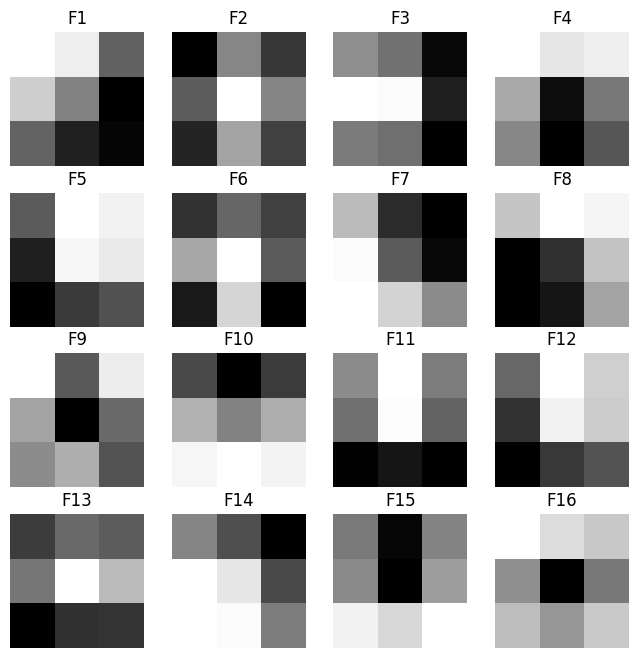

Saved: /content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-D/cnn_filters.png


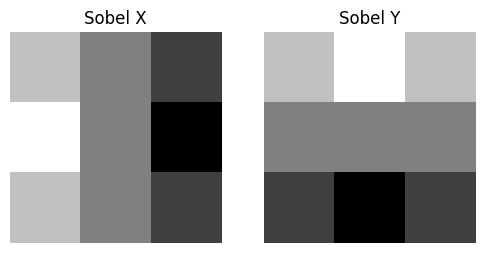

Saved: /content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-D/sobel.png
✅ PART D DONE


In [15]:
#cell No: 7

def main():
    # Load model
    model = load_model()

    # Extract filters
    filters = extract_filters(model, layer_index=1)

    # Normalize
    filters = normalize_filters(filters)

    # Visualize filters
    plot_filters(filters, filename="cnn_filters.png")

    # Sobel comparison
    sobel_x, sobel_y = get_sobel_kernels()
    plot_sobel(sobel_x, sobel_y)


main()